In [16]:
from helpers.sporc import (
    SPORCDataset
)
from pprint import pprint
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import plotly.express as px
import pandas as pd
import re
import nltk
import string
from nltk.corpus import stopwords

In [17]:
sporc = SPORCDataset(local_data_dir="data", load_samples_only=True)

INFO:helpers.sporc.dataset:Loading SPORC dataset from local directory: data
INFO:helpers.sporc.dataset:Loading SPORC sample dataset only.
INFO:helpers.sporc.dataset:✓ All required files found
INFO:helpers.sporc.dataset:Loading all records from local files into memory...
INFO:helpers.sporc.dataset:Loading episode_data_sample...
INFO:helpers.sporc.dataset:Loading speaker_turn_data_sample...
INFO:helpers.sporc.dataset:✓ Loaded 210,000 total records from 2 files
INFO:helpers.sporc.dataset:✓ Local dataset loaded successfully in 18.03 seconds
INFO:helpers.sporc.dataset:✓ Dataset loaded successfully with 210000 total records
INFO:helpers.sporc.dataset:Processing dataset into Podcast and Episode objects...
INFO:helpers.sporc.dataset:Separating episode data from speaker turn data...


Loading episodes:   0%|          | 0/210000 [00:00<?, ?it/s]

INFO:helpers.sporc.dataset:✓ Separation completed in 1.75 seconds
INFO:helpers.sporc.dataset:  Episode records: 10,000, Speaker turn records: 200,000
INFO:helpers.sporc.dataset:Grouping episodes by podcast...
INFO:helpers.sporc.dataset:✓ Grouping completed in 0.10 seconds
INFO:helpers.sporc.dataset:  Episodes grouped into 1826 podcasts
INFO:helpers.sporc.dataset:Creating Podcast and Episode objects...
INFO:helpers.sporc.dataset:✓ Object creation completed in 2.56 seconds
INFO:helpers.sporc.dataset:Loading speaker turn data for episodes...
INFO:helpers.sporc.dataset:Loading turn data for 200,000 speaker turn records...
INFO:helpers.sporc.dataset:Grouping turns by episode URL...
INFO:helpers.sporc.dataset:✓ Turn grouping completed in 0.34 seconds
INFO:helpers.sporc.dataset:  Turns grouped into 1,033 episodes
INFO:helpers.sporc.dataset:Loading turns for each episode...
INFO:helpers.sporc.dataset:✓ Turn loading completed in 5.16 seconds
INFO:helpers.sporc.dataset:  Episodes with turns: 1,0

In [18]:
# initial idea for detection of interruptions
episodes = sporc.get_all_episodes()

interruptions = []

for episode in episodes:
    turns = episode.get_all_turns()
    for i in range(len(turns)-1):
        if turns[i].end_time > turns[i+1].start_time and turns[i].speaker != turns[i+1].speaker:
            interruptions.append(turns[i+1].text)

In [19]:
#preprocessing pipeline
#remove outliers with isolation forests e.g?

stop_words = set(stopwords.words("english"))

def is_meaningless_single_word(s):

    text = s.strip().lower()
    text = text.strip(string.punctuation)
    words = text.split()
    if len(words) != 1:  #multi-word → potentially meaningful
        return False

    w = words[0]

    # too short (1-2 chars)
    if len(w) <= 2:
        return True

    # stopwords → usually not standalone interruptions
    if w in stop_words:
        return True

    # remove nonsensical words (e.g. "'re", "n't")
    if not w.isalpha():
        return True

    # otherwise it's meaningful ("wait", "stop", "listen")
    return False

def keep_interruption(s):
    # remove pure punctuation
    if all(ch in string.punctuation or ch.isspace() for ch in s):
        return False
    
    # remove meaningless one-word fragments
    if is_meaningless_single_word(s):
        return False

    return True

clean_interruptions = [s for s in interruptions if keep_interruption(s)]
print(len(clean_interruptions), "cleaned interruptions out of", len(interruptions))
pprint(clean_interruptions)

180 cleaned interruptions out of 215
[', failed it at schoolcraft, failed it once at Eastern, and then, uh, who '
 'got, I think I, uh, I won, like, had to do a placement test and I, uh, '
 'completed the placement test by one point and each question was worth seven '
 'points, so God knows how I did that. And then, uh, I took an online class so '
 "I could cheat, because I knew I wasn't going to pass it. Yeah, you got a, "
 'you got a cheat. Yeah, I took the baby, baby math in college. Like, the '
 "final project was like writing a yearly budget. [laughter] He's not like the "
 'starting salary for your career. It was so easy. It was like trash math, but '
 "like, it counted. Um, yeah, if you fail it three times, that's, that's, "
 "that's when it becomes a hobby. Yeah, that point skateboarding is just a "
 'hobby. [laughter] Yeah, what we were saying earlier is skateboarding is a '
 'way to express myself. Okay. Dan, Dan, Kev, yelling at it. Dad, this is how '
 'I express myself. Yea

In [20]:
#sentence embeddings
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
embeddings = model.encode(clean_interruptions)

INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-mpnet-base-v2


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

In [21]:
#compute silhouette scores to find optimal clustering
def evaluate_k_range(X, k_min=2, k_max=15):
    scores = {}

    for k in range(k_min, k_max + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        scores[k] = score
        print(f"k={k} → silhouette={score:.4f}")

    return scores

scores = evaluate_k_range(embeddings)

#k-means
k = 5  
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(embeddings)
for text, label in zip(clean_interruptions, labels):
    print(f"[Cluster {label}] {text}")


k=2 → silhouette=0.0321
k=3 → silhouette=0.0289
k=4 → silhouette=0.0283
k=5 → silhouette=0.0330
k=6 → silhouette=0.0306
k=7 → silhouette=0.0245
k=8 → silhouette=0.0306
k=9 → silhouette=0.0216
k=10 → silhouette=0.0267
k=11 → silhouette=0.0253
k=12 → silhouette=0.0291
k=13 → silhouette=0.0297
k=14 → silhouette=0.0362
k=15 → silhouette=0.0281
[Cluster 2] , failed it at schoolcraft, failed it once at Eastern, and then, uh, who got, I think I, uh, I won, like, had to do a placement test and I, uh, completed the placement test by one point and each question was worth seven points, so God knows how I did that. And then, uh, I took an online class so I could cheat, because I knew I wasn't going to pass it. Yeah, you got a, you got a cheat. Yeah, I took the baby, baby math in college. Like, the final project was like writing a yearly budget. [laughter] He's not like the starting salary for your career. It was so easy. It was like trash math, but like, it counted. Um, yeah, if you fail it three 

In [22]:
#interpret cluster centers
cluster_centers = kmeans.cluster_centers_
for c in range(k):
    print(f"\nCluster {c} examples:")
    idxs = np.where(labels == c)[0][:2] # show 2 examples per cluster
    for i in idxs:
        print("  ", clean_interruptions[i])


Cluster 0 examples:
    It's always been the problem that people are sleeping. So I want you to turn with me to Psalm 81. And I want to read some verses that are phenomenal. Because not everything that happens is God's will. Sometimes people say, "Oh, this terrible thing happened. It must be God's will." That is such ridiculous thinkology. Let me read something to you about his Old Testament people. Psalm 81, look at it with me. Verse 13, God cries. He actually is really, really passionate here. He says, "Oh, that my people had hearkened unto me." And Israel had walked in my ways. You know, the word hearkened the root word is here. You know, we need to hear what the Spirit would say. We need to be awakened. And so they didn't hear. And God says, "Oh, that my people would have hearkened unto me." And Israel had walked in my ways. And look what he says, "I should soon have subdued their enemies and turned against their adversaries." Verse 15, "The haters of the Lord should have submitte

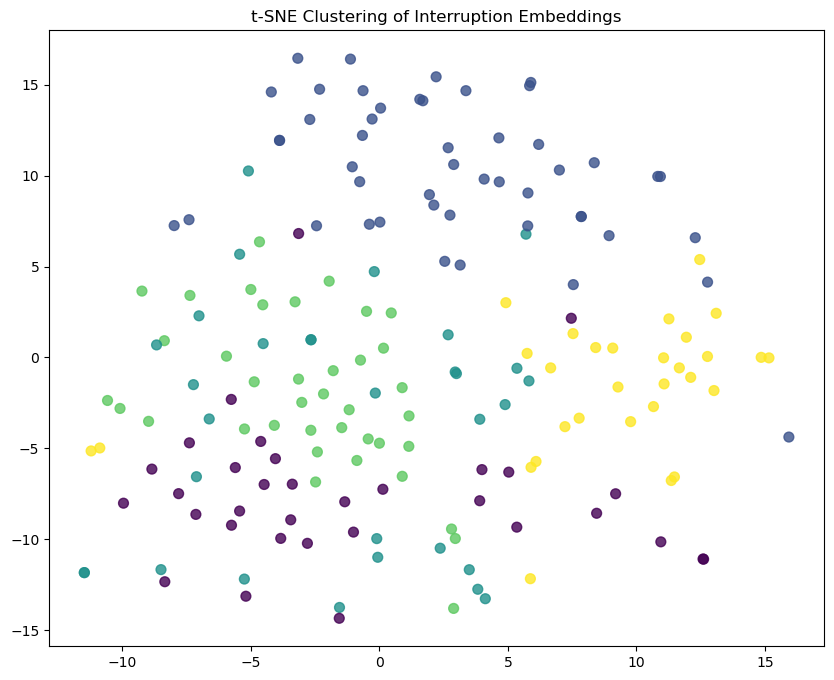

In [23]:
#t-SNE visualization of clusters
tsne = TSNE(
    n_components=2,
    random_state=42
)

tsne_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    tsne_2d[:,0], 
    tsne_2d[:,1], 
    c=labels, 
    s=50,
    alpha=0.8
)

#plt.colorbar(scatter)
plt.title("t-SNE Clustering of Interruption Embeddings")
plt.show()


In [24]:
#t-SNE in 3D 
tsne = TSNE(
    n_components=3,
    random_state=0
)
projections = tsne.fit_transform(embeddings)  

df_plot = pd.DataFrame({
    'x': projections[:, 0],
    'y': projections[:, 1],
    'z': projections[:, 2],
    'cluster': labels,               
    'text': clean_interruptions            
})

fig = px.scatter_3d(
    df_plot,
    x='x', y='y', z='z',
    color='cluster',
    hover_name='text',               
    labels={'color': 'cluster'}
)

fig.update_traces(marker_size=4)
fig.show()